In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast

In [3]:
df1 = pd.read_csv("games_march2025_cleaned.csv")
df2 = pd.read_csv("extended_dataset_2.csv", low_memory=False)

df = df2.merge(
    df1[['appid', 'peak_ccu', 'tags', 'genres']],
    on='appid',
    how='inner'
)

In [4]:
df['min_storage'] = pd.to_numeric(df['min_storage'], errors='coerce')
df['rec_storage'] = pd.to_numeric(df['rec_storage'], errors='coerce')

df['storage'] = df[['min_storage', 'rec_storage']].min(axis=1)

df['release_date'] = pd.to_datetime(
    df['release_date'],
    errors='coerce',
    format='mixed'
)

df['year'] = df['release_date'].dt.year

# Genre/ Tag Weighted Analysis

In [6]:
df['tags'].iloc[0]

'{\'Action\': 766, \'FPS\': 332, \'Multiplayer\': 279, \'Classic\': 254, \'Hero Shooter\': 226, \'Shooter\': 223, \'Team-Based\': 201, \'Class-Based\': 196, \'First-Person\': 187, "1990\'s": 162, \'Old School\': 123, \'Co-op\': 98, \'Competitive\': 82, \'Fast-Paced\': 73, \'Retro\': 68, \'Online Co-Op\': 60, \'Violent\': 56, \'Funny\': 40, \'Mod\': 39, \'Remake\': 39}'

In [7]:
df['tags'] = df['tags'].apply(
    lambda x: ast.literal_eval(x) if pd.notnull(x) else {}
)

In [8]:
target_tags = [
    "RPG",
    "Action",
    "Indie",
    "Open World",
    "Survival",
    "Strategy",
    "FPS"
]

In [11]:
df = df[df['storage'] < 500]

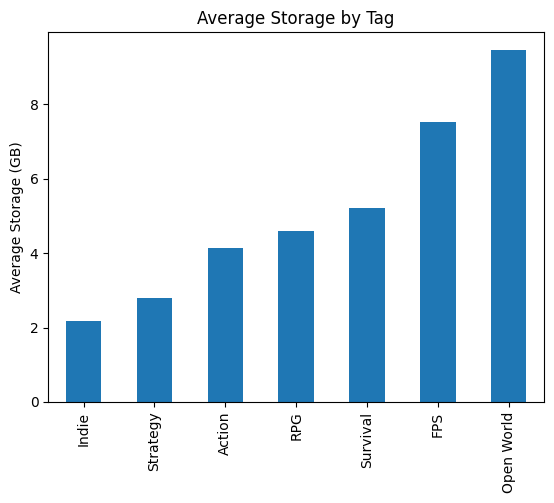

In [12]:
tag_storage = {}

for tag in target_tags:

    subset = df[
        df['tags'].apply(
            lambda t: tag in t if isinstance(t, dict) else False
        )
    ]

    tag_storage[tag] = subset['storage'].mean()

tag_storage_series = pd.Series(tag_storage)

tag_storage_series.sort_values().plot(kind='bar')

plt.title("Average Storage by Tag")
plt.ylabel("Average Storage (GB)")
plt.show()

/var/folders/3x/pswb2gc16dj3h0v43n8_d6kw0000gn/T/ipykernel_35211/1655520144.py:13: RuntimeWarning: invalid value encountered in scalar divide
  (g['storage'] * g['peak_ccu']).sum()
/var/folders/3x/pswb2gc16dj3h0v43n8_d6kw0000gn/T/ipykernel_35211/1655520144.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(
/var/folders/3x/pswb2gc16dj3h0v43n8_d6kw0000gn/T/ipykernel_35211/1655520144.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns afte

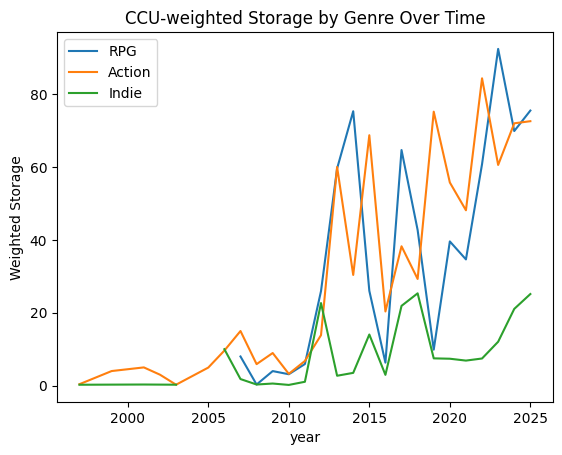

In [13]:
for tag in ["RPG", "Action", "Indie"]:

    subset = df[
        df['tags'].apply(
            lambda t: tag in t if isinstance(t, dict) else False
        )
    ]

    yearly = (
        subset.groupby('year')
              .apply(
                  lambda g:
                  (g['storage'] * g['peak_ccu']).sum()
                  / g['peak_ccu'].sum()
              )
    )

    yearly.plot(label=tag)

plt.legend()
plt.title("CCU-weighted Storage by Genre Over Time")
plt.ylabel("Weighted Storage")
plt.show()

# Heavy Game Domination

In [14]:
top_games = df.sort_values("peak_ccu", ascending=False)

In [15]:
top_1_percent = int(len(df) * 0.01)

top_ccu_share = (
    top_games.head(top_1_percent)["peak_ccu"].sum()
    / top_games["peak_ccu"].sum()
)

print(top_ccu_share)

0.9456510715964334


In [16]:
top_storage = (
    top_games.head(top_1_percent)["storage"].mean()
)

overall_storage = df["storage"].mean()

print("Top 1% avg storage:", top_storage)
print("Overall avg storage:", overall_storage)

Top 1% avg storage: 28.605091575091574
Overall avg storage: 3.0870827325378523


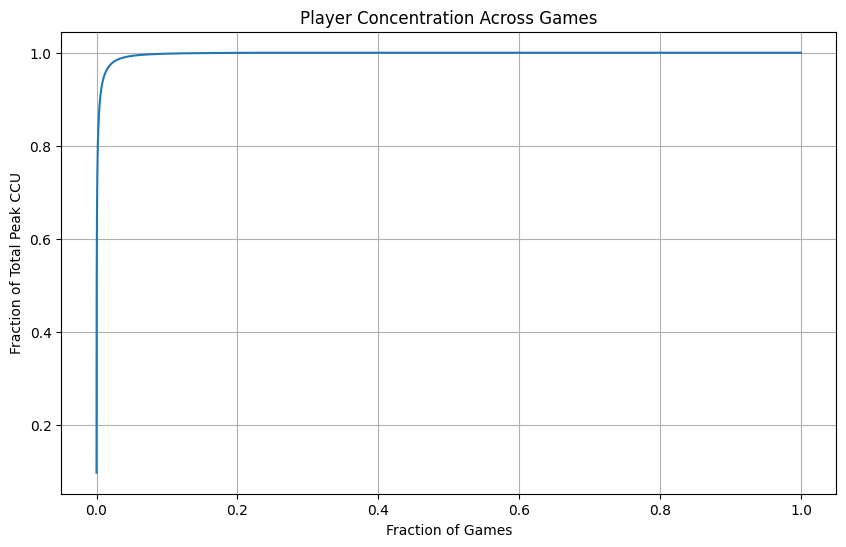

In [17]:
top_games['cumulative_ccu'] = (
    top_games['peak_ccu'].cumsum()
    / top_games['peak_ccu'].sum()
)

top_games['percentile'] = (
    np.arange(len(top_games)) / len(top_games)
)

plt.figure(figsize=(10,6))

plt.plot(
    top_games['percentile'],
    top_games['cumulative_ccu']
)

plt.title("Player Concentration Across Games")
plt.xlabel("Fraction of Games")
plt.ylabel("Fraction of Total Peak CCU")

plt.grid(True)
plt.show()

Top 1,5,10%

In [18]:
for pct in [0.01, 0.05, 0.10]:

    top_n = int(len(top_games) * pct)

    share = (
        top_games.head(top_n)["peak_ccu"].sum()
        / top_games["peak_ccu"].sum()
    )

    print(pct, share)

0.01 0.9456510715964334
0.05 0.9931165324669532
0.1 0.9979862838401131


In [24]:
df_plot = df[df['storage'] < 200]

In [22]:
top_1_storage = (
    top_games.head(top_n)["storage"].mean()
)

overall_storage = df["storage"].mean()

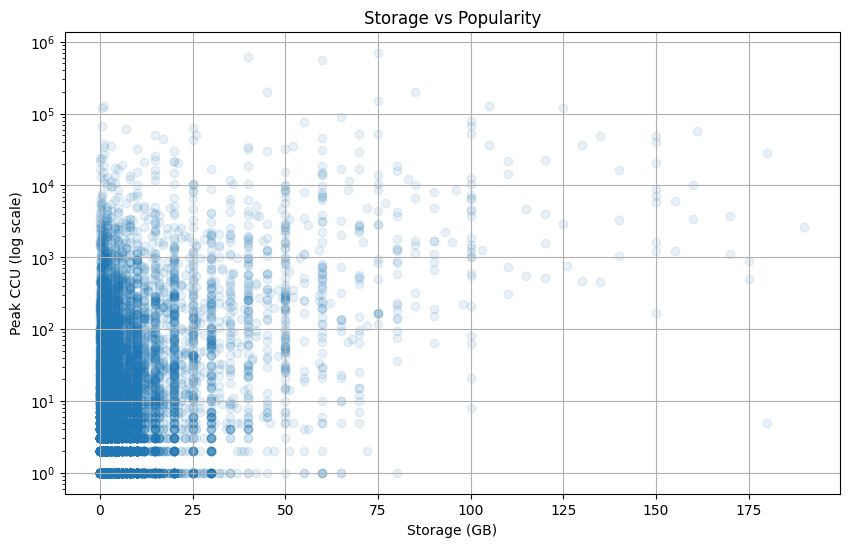

In [26]:
plt.figure(figsize=(10,6))

plt.scatter(
    df_plot['storage'],
    df_plot['peak_ccu'],
    alpha=0.1
)

plt.yscale('log')

plt.xlabel("Storage (GB)")
plt.ylabel("Peak CCU (log scale)")
plt.title("Storage vs Popularity")

plt.grid(True)
plt.show()

Which games achieve high popularity with low hardware/storage demands? (Popularity per GB)

In [28]:
df['ccu_per_gb'] = (
    df['peak_ccu'] / (df['storage'] + 1)
)

df_eff = df[
    (df['storage'] > 0)
    & (df['peak_ccu'] > 100)
]



In [29]:
efficient_games = df_eff.sort_values(
    'ccu_per_gb',
    ascending=False
)

efficient_games[
    ['name', 'storage', 'peak_ccu', 'ccu_per_gb']
].head(20)

,name,storage,peak_ccu,ccu_per_gb
7124,Wallpaper Engine,0.512,120461,79669.973545
84998,R.E.P.O.,1.000,127336,63668.000000
6553,Stardew Valley,0.500,67309,44872.666667
13875,Soundpad,0.020,21589,21165.686275
65000,Balatro,0.150,24326,21153.043478
7367,VRChat,1.000,37954,18977.000000
23592,Valheim,1.000,33903,16951.500000
1330,The Binding of Isaac: Rebirth,0.449,24316,16781.228433
3234,Geometry Dash,0.100,17019,15471.818182
12153,PUBG: BATTLEGROUNDS,40.000,616738,15042.390244


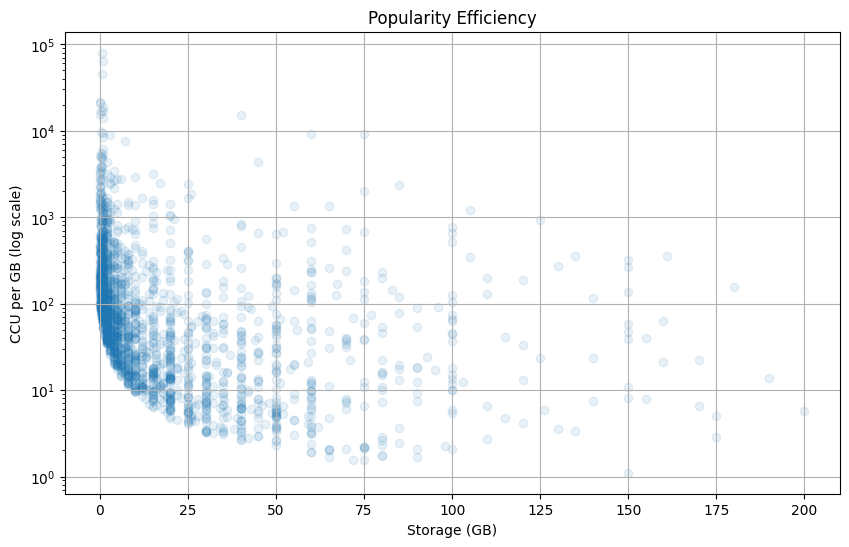

In [30]:
plt.figure(figsize=(10,6))

plt.scatter(
    df_eff['storage'],
    df_eff['ccu_per_gb'],
    alpha=0.1
)

plt.yscale('log')

plt.xlabel("Storage (GB)")
plt.ylabel("CCU per GB (log scale)")
plt.title("Popularity Efficiency")

plt.grid(True)
plt.show()

annotate famous outliers

In [33]:
highlight_games = [
    "Stardew Valley",
    "PUBG: BATTLEGROUNDS",
    "The Binding of Isaac: Rebirth",
    "Wallpaper Engine"
]

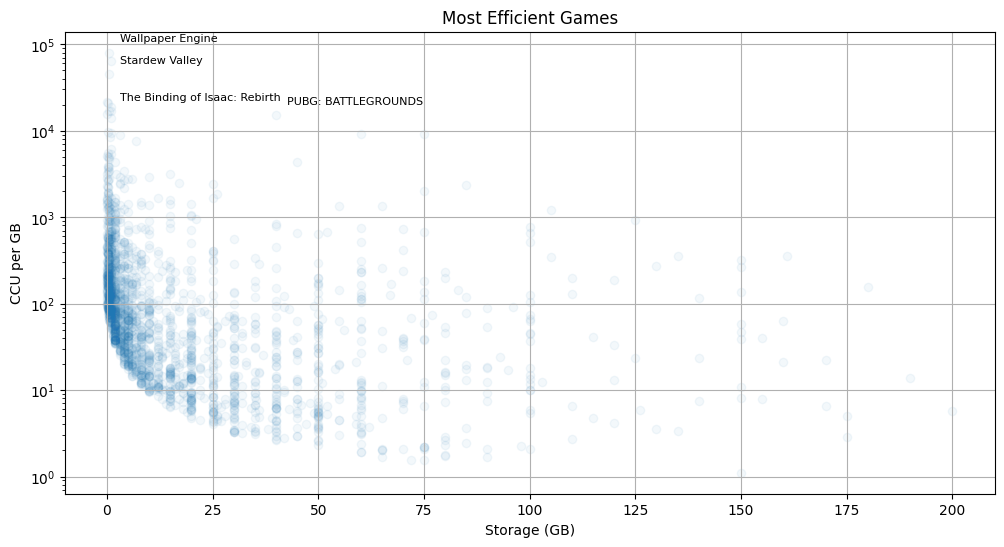

In [40]:
plt.figure(figsize=(12,6))

plt.scatter(
    df_eff['storage'],
    df_eff['ccu_per_gb'],
    alpha=0.05
)

highlight_df = efficient_games[
    efficient_games['name'].isin(highlight_games)
]

for _, row in highlight_df.iterrows():

    plt.annotate(
        row['name'],
        (row['storage'], row['ccu_per_gb']),
        xytext=(8, 8),
        textcoords='offset points',
        fontsize=8
    )

plt.yscale('log')

plt.xlabel("Storage (GB)")
plt.ylabel("CCU per GB")
plt.title("Most Efficient Games")

plt.grid(True)
plt.show()